# Task 2: Credit Risk Prediction

## Introduction
This notebook solves **Task 2: Credit Risk Prediction** for the Data Science & Analytics Internship task.

The main goal is to predict whether a loan application is approved or not using applicant details such as income, loan amount, education, credit history, and property area.

## Problem Statement
Banks and financial institutions receive many loan applications. A machine learning model can help analyze applicant information and predict the loan status. This can support faster and more data-driven decision making.


## 1. Import Required Libraries
We will use pandas and numpy for data handling, matplotlib and seaborn for visualization, and scikit-learn for machine learning.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Show plots inside notebook
%matplotlib inline

# Optional: make plot size better
plt.rcParams['figure.figsize'] = (8, 5)


## 2. Load the Dataset
The Loan Prediction dataset is loaded from a public GitHub CSV source. If the link does not work, you can download the dataset from Kaggle and upload the CSV manually in Colab.

In [2]:
# Load dataset from public URL
url = 'https://raw.githubusercontent.com/Architectshwet/Loan-prediction-using-Machine-Learning-and-Python/master/data/train_u6lujuX_CVtuZ9i.csv'

df = pd.read_csv(url)

# Display first five rows
df.head()


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## 3. Dataset Understanding
Here we check the shape, columns, basic information, and missing values in the dataset.

In [5]:
# Dataset shape
print('Dataset Shape:', df.shape)

# Column names
print('Columns:')
print(df.columns)

# Dataset information
print('Dataset Info:')
df.info()


Dataset Shape: (614, 13)
Columns:
Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')
Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564

In [6]:
# Summary statistics for numerical columns
df.describe()


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [7]:
# Check missing values
missing_values = df.isnull().sum()
missing_values


,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


## 4. Data Cleaning and Preparation
The dataset contains missing values. We will fill missing numerical values using median and categorical values using mode.

We will also remove the `Loan_ID` column because it is only an identifier and does not help in prediction.

In [8]:
# Make a copy of the original dataset
loan_df = df.copy()

# Drop Loan_ID because it is not useful for prediction
loan_df = loan_df.drop('Loan_ID', axis=1)

# Fill missing values
for column in loan_df.columns:
    if loan_df[column].dtype == 'object':
        loan_df[column] = loan_df[column].fillna(loan_df[column].mode()[0])
    else:
        loan_df[column] = loan_df[column].fillna(loan_df[column].median())

# Confirm missing values are handled
loan_df.isnull().sum()


,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0
Credit_History,0


## 5. Exploratory Data Analysis (EDA)
Now we will visualize important features such as loan amount, education, and applicant income.

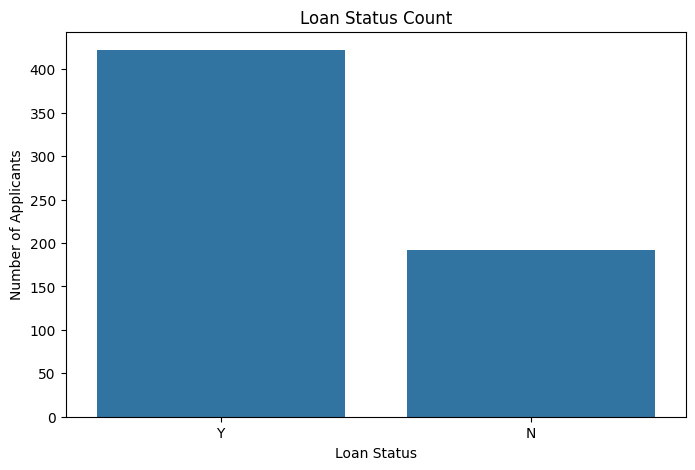

In [9]:
# Loan status count
sns.countplot(data=loan_df, x='Loan_Status')
plt.title('Loan Status Count')
plt.xlabel('Loan Status')
plt.ylabel('Number of Applicants')
plt.show()


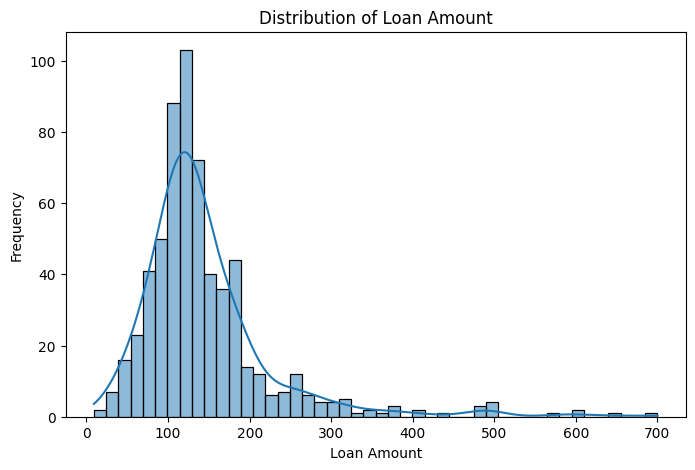

In [10]:
# Loan amount distribution
sns.histplot(data=loan_df, x='LoanAmount', kde=True)
plt.title('Distribution of Loan Amount')
plt.xlabel('Loan Amount')
plt.ylabel('Frequency')
plt.show()


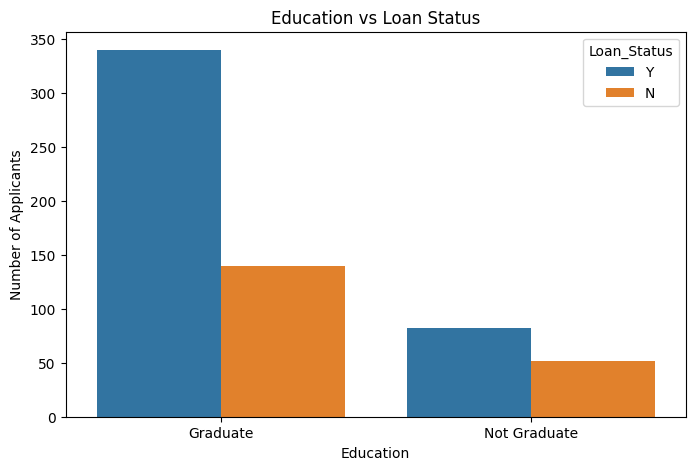

In [11]:
# Education vs Loan Status
sns.countplot(data=loan_df, x='Education', hue='Loan_Status')
plt.title('Education vs Loan Status')
plt.xlabel('Education')
plt.ylabel('Number of Applicants')
plt.show()


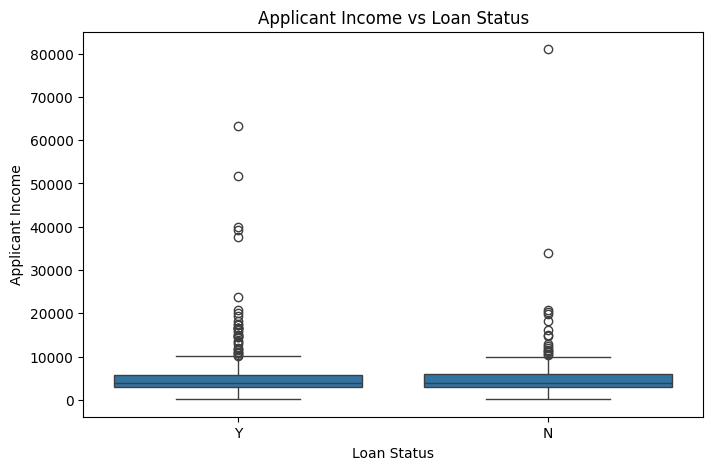

In [12]:
# Applicant income vs Loan Status
sns.boxplot(data=loan_df, x='Loan_Status', y='ApplicantIncome')
plt.title('Applicant Income vs Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Applicant Income')
plt.show()


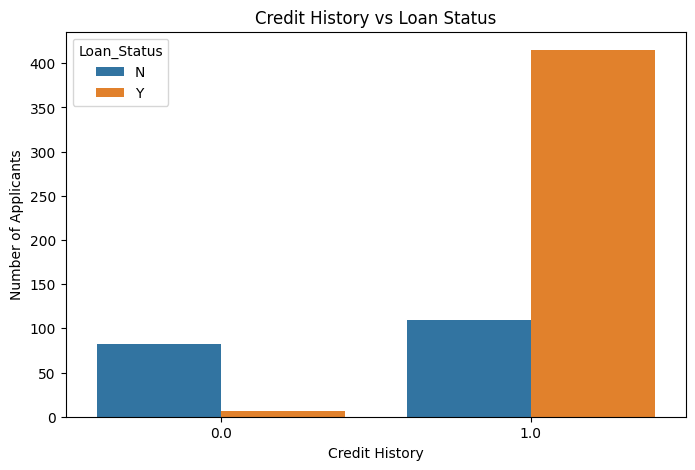

In [13]:
# Credit History vs Loan Status
sns.countplot(data=loan_df, x='Credit_History', hue='Loan_Status')
plt.title('Credit History vs Loan Status')
plt.xlabel('Credit History')
plt.ylabel('Number of Applicants')
plt.show()


## 6. Encode Categorical Features
Machine learning models need numerical input. So, we convert categorical columns such as Gender, Married, Education, Property_Area, and Loan_Status into numbers using Label Encoding.

In [14]:
# Encode categorical columns
encoded_df = loan_df.copy()

label_encoders = {}
for column in encoded_df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    encoded_df[column] = le.fit_transform(encoded_df[column])
    label_encoders[column] = le

encoded_df.head()


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


## 7. Split Data into Training and Testing Sets
We separate the input features and the target variable. The target variable is `Loan_Status`.

In [15]:
# Features and target
X = encoded_df.drop('Loan_Status', axis=1)
y = encoded_df['Loan_Status']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Training set size:', X_train.shape)
print('Testing set size:', X_test.shape)


Training set size: (491, 11)
Testing set size: (123, 11)


## 8. Train Classification Model
We will use a Decision Tree Classifier because it is easy to understand and works well for classification problems.

In [16]:
# Create and train Decision Tree model
model = DecisionTreeClassifier(random_state=42, max_depth=4)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)


## 9. Model Evaluation
We evaluate the model using accuracy, confusion matrix, and classification report.

In [17]:
# Accuracy score
accuracy = accuracy_score(y_test, y_pred)
print('Model Accuracy:', round(accuracy, 4))


Model Accuracy: 0.8455


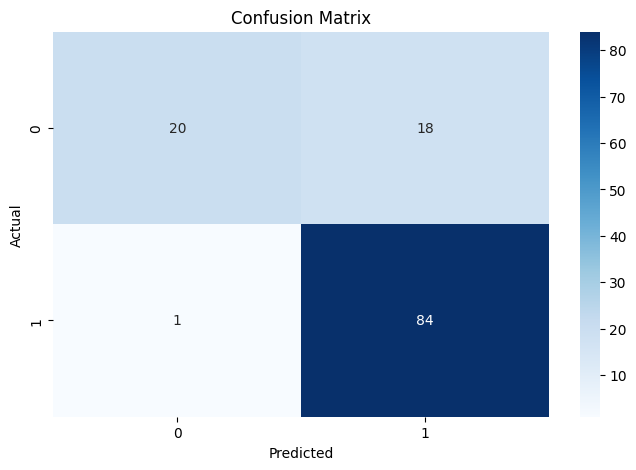

In [18]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [19]:
# Classification report
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.95      0.53      0.68        38
           1       0.82      0.99      0.90        85

    accuracy                           0.85       123
   macro avg       0.89      0.76      0.79       123
weighted avg       0.86      0.85      0.83       123



## 10. Feature Importance
Feature importance helps us understand which features were more useful for prediction.

In [20]:
# Feature importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

importance


,Feature,Importance
9,Credit_History,0.799855
7,LoanAmount,0.111998
6,CoapplicantIncome,0.057269
5,ApplicantIncome,0.030878
2,Dependents,0.000000
0,Gender,0.000000
1,Married,0.000000
3,Education,0.000000
4,Self_Employed,0.000000
8,Loan_Amount_Term,0.000000


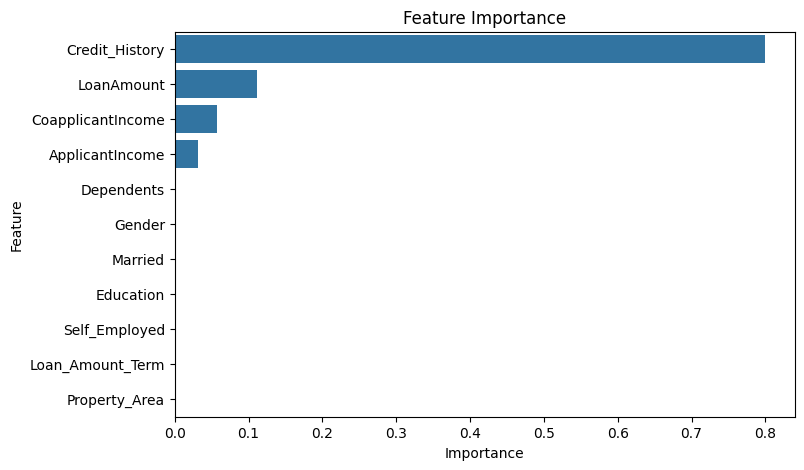

In [21]:
# Plot feature importance
sns.barplot(data=importance, x='Importance', y='Feature')
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()


## 11. Conclusion
In this task, we built a simple classification model to predict loan status using the Loan Prediction dataset.

### Key Findings
- Missing values were handled using median for numerical columns and mode for categorical columns.
- Important features such as loan amount, education, applicant income, and credit history were visualized.
- A Decision Tree Classifier was trained to predict loan status.
- The model was evaluated using accuracy and confusion matrix.
- Credit history usually appears as one of the most important features for loan approval prediction.

### Final Note
This task helped in understanding data cleaning, EDA, classification modeling, and model evaluation using Python.
